In [1]:
# change this to your path with the data directory
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

In [2]:
import sys
# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 

# just to make the cells appear wider: comment these lines if needed. 
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


import pandas as pd
import seaborn as sns # only used for nice colors



In [3]:


def obtain_channels_list(complete_path='complete/path/to/data.csv'):
    """ returns list with channel column headers """
    df = pd.read_csv(complete_path)
    return df.columns.values[1:-1] # -1 because the last column is total rates. 


def obtain_total_header(complete_path='complete/path/to/data.csv'):
    """ returns column header for total """
    df = pd.read_csv(complete_path)
    return df.columns.values[-1] # -1 because the last column is total rates.     


def obtain_formation_channel_colors():
    channel_color_names = ['channel I intrinsic (z=0) classic', 'channel II intrinsic (z=0) OSMT', 'channel III intrinsic (z=0) SCCE',  'channel IV intrinsic (z=0) DCCE', 'channel V intrinsic (z=0) other']
    channel_colors = ['#118AB2',  'orange', '#EF476F','#073B4C',  'gray'] #['#118AB2',  '#FFD166', '#EF476F','#073B4C',  'gray']
    fc_color_dict = {channel_color_names[i]: channel_colors[i] for i in range(len(channel_color_names))}
    
    return fc_color_dict


def draw_hlines(axe, v_values, list_h_values=[1E-3, 1E5]):
    """ draws lightgray custom vertical grid lines at values in the v_values list 
    these are drawn between the horizontal values given by list_h_values
    """
    for v_ in v_values:
        axe.plot(list_h_values, [v_, v_], lw=0.5, c='gray', ls=':', zorder=0)
        
    return 


def plot_observed_GWrate(axe, DCOlabel='BH-BH', lenmodels=10):
    # plot observed rates (make this a better function )
    dict_rates_from_DCOlabel = {"BH-BH":[10.3, 61.0], "BH-NS":[8,  140.0], "NS-NS":[10.0, 1700.0]}
    # NSNS rates Gpc-3 yr-1 from:GWTC3 min & max rates 
    # BHBH rates for minimum and maximum of possible local merger rates estimates,  and https://ui.adsabs.harvard.edu/abs/2021arXiv210801045T/abstract
    # BHNS rate min and max range from the two estimates based on GW200115 and GW200105!! (OLD) ! 
    
    min_obs_rate, max_obs_rate = dict_rates_from_DCOlabel[DCOlabel][0], dict_rates_from_DCOlabel[DCOlabel][1]
    axe.fill_betweenx(y=[-1, lenmodels], x1=[min_obs_rate,min_obs_rate], x2=[max_obs_rate,max_obs_rate], alpha=0.8, color='lightgray', zorder=1)
        

    return


def plot_formation_channels_fraction(axe, complete_path='complete/path/to/data.csv', sort_column=None):
    """   
    
    """

    channel_headers = obtain_channels_list(complete_path=complete_path)
    total_header = obtain_total_header(complete_path=complete_path)
    
    fc_color_dict = obtain_formation_channel_colors() # obtain formation channel colors 
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    
    df = pd.read_csv(complete_path)
    df = df.sort_values(sort_column).reset_index(drop=True)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    #.reset_index(drop=True) resets the index, so that index = 0 is the first element in the sorted list (not original list)
    
    
    models = df['model'] # models that are available 
    plot_size_normalizer = 1 # change to be related to figure size and number of models to keep figure consistent size

    for ind_m, model in enumerate(models):
        total_rate, fc_fraction_low, fc_fraction_up = df[total_header][ind_m], 0, 0
        for ind_c, channel in enumerate(channel_headers):
            color_c = fc_color_dict[channel]
            fc_fraction_up += df[channel].values[ind_m] 
            y_value        = ind_m / plot_size_normalizer # 
            
            axe.plot([fc_fraction_low, fc_fraction_up], [y_value,y_value], lw=10, color=color_c, zorder=5) #, marker='o') 
            fc_fraction_low += df[channel].values[ind_m]
    
    axe.set_ylim(-1, len(models)+0.25)
    axe.set_xlim(0, 1)
    axe.set_xticks(np.arange(0,1+0.1, 0.1))
    layoutAxesNoYlabel(ax=axe, nameX=r'$\textbf{fraction}$', nameY=False, noYticks=True, setMinor=False)
    
    axe.grid(True)
    
    return axe


def plot_total_rate(axe, complete_path='complete/path/to/data.csv', sort_column=None, DCOlabel='BH-BH'):
    """ plots total rates on provided axe plot 
    """


    channel_headers = obtain_channels_list(complete_path=complete_path)
    total_header = obtain_total_header(complete_path=complete_path)
    
    fc_color_dict = obtain_formation_channel_colors() # obtain formation channel colors 
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    
    df = pd.read_csv(complete_path)
    df = df.sort_values(sort_column).reset_index(drop=True)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    #.reset_index(drop=True) resets the index, so that index = 0 is the first element in the sorted list (not original list)
    
    models = df['model'] # models that are available     
    plot_size_normalizer = 1 # change to be related to figure size and number of models to keep figure consistent size
    
    for ind_m, model in enumerate(models):
        
        total_rate = df[total_header][ind_m]
        y_value        = ind_m / plot_size_normalizer # 
        axe.scatter(total_rate, y_value, s=60, color=['k'], zorder=10, marker='d') 

        draw_hlines(axe=axe, v_values=[y_value]) # add custom grid lines
    
    axe.set_ylim(-1, len(models)+0.25)
    xlabel = r'$\mathcal{R}_{\rm{m}} \ [ \rm{Gpc}^{-3} \rm{yr}^{-1} ] $' #\rm{Gpc}^{-3}\,\rm{yr}^{-1}
    layoutAxesNoYlabel(ax=axe, nameX=xlabel, nameY=False, noYticks=True) #, fontsize=20)
    
    axe.set_xscale('log')
    dictDCOlabel_xlim = {"BH-BH":[2, 500], "BH-NS":[0.2,400], "NS-NS":[0.5, 2*1E3]} # limits for the x-axis range for each DCO type 
    axe.set_xlim(dictDCOlabel_xlim[DCOlabel][0], dictDCOlabel_xlim[DCOlabel][1])
    
    ## add observed merger rates
    lenmodels = len(models)+0.25
    plot_observed_GWrate(axe, DCOlabel, lenmodels)
    

    return axe




def plot_formation_channels_rate(axe, complete_path='complete/path/to/data.csv', sort_column=None): #, ind_channels=[0,1, 2, 3]):


    channel_headers = obtain_channels_list(complete_path=complete_path) 
    total_header = obtain_total_header(complete_path=complete_path)
    
    fc_color_dict = obtain_formation_channel_colors() # obtain formation channel colors 
    
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    
    
    df = pd.read_csv(complete_path)
    df = df.sort_values(sort_column).reset_index(drop=True)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    #.reset_index(drop=True) resets the index, so that index = 0 is the first element in the sorted list (not original list)
    
    models = df['model'] # models that are available 
    plot_size_normalizer = 1 # change to be related to figure size and number of models to keep figure consistent size
    for ind_m, model in enumerate(models):
        total_rate = df[total_header][ind_m]
        for ind_c, channel in enumerate(channel_headers):
            color_c = fc_color_dict[channel]
            y_value        = ind_m / plot_size_normalizer # 
            channel_rate = df[channel].values[ind_m]*total_rate
            
            axe.scatter(channel_rate, y_value, s=50, color=[color_c], zorder=5, marker='s', facecolor='none') 
    
    return axe





def plot_simulation_properties(axe, specs_path='complete/path/to/simulation_specs.csv', complete_path='complete/path/to/simulation_specs.csv', sort_column=None):

    channel_headers = obtain_channels_list(complete_path=complete_path) 
    
    
    
    
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    df_rates = pd.read_csv(complete_path) # path with the rates 
    df_rates = df_rates.sort_values(sort_column)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    
    # read in model specifications and order it the same way as the rate models (based on sort_column)
    df = pd.read_csv(specs_path)
    df = df.set_index('model')
    df = df.reindex(index=df_rates['model'])
    df = df.reset_index()
    
    models = df['model'] # models that are available 
    plot_size_normalizer = 1 # change in the future to be related to figure size and number of models to keep figure consistent size
    author_dict, code_dict, tracks_dict, labeli_dict, labelii_dict = obtain_models_colors(specs_path, "label_author", "husl"), obtain_models_colors(specs_path, "code", "husl"), obtain_models_colors(specs_path, "stellar_tracks", "husl"),\
    obtain_models_colors(specs_path, "label_1", "husl"), obtain_models_colors(specs_path, "label_1", "husl") # colors for label 1 are the same as label 2 
    
    
    xpositions = 0.02 + np.asarray([-0.2, 0, 0.3, 0.51, 0.8]) #, 0.75])
    for ind_m, model in enumerate(models[:]):
#         
        specs_labels = [df["label_author"][ind_m], df["code"][ind_m], df["stellar_tracks"][ind_m], df["label_1"][ind_m] , df["label_2"][ind_m]]
        colors_ = [author_dict[df["label_author"][ind_m]], code_dict[df["code"][ind_m]], tracks_dict[df["stellar_tracks"][ind_m]], labeli_dict[df["label_1"][ind_m]] , labelii_dict[df["label_2"][ind_m]]] # 
        y_value        = ind_m / plot_size_normalizer # 
        
        
        for ind_xpos, xpos in enumerate(xpositions):
            text = r'\textbf{%s}'%specs_labels[ind_xpos]
            axe.text(xpos, y_value, s=text, ha='left', va='center', fontsize=9, fontproperties='bold', color=colors_[ind_xpos])
    
    
    
    # add headers to the specs
    labels = [r'$\textbf{name}$', r'$\textbf{code}$', r'$\textbf{tracks}$', r'$\textbf{var1}$', r'$\textbf{var2}$']
    for ind_xpos, xpos in enumerate(xpositions):
        
        axe.text(xpos, y_value+1.2, s=labels[ind_xpos], ha='left', va='top', fontsize=12)
    
    axe.set_ylim((-1, len(models)+0.25))
    axe.set_xlim(0, 1)
#     layoutAxesNoXandYlabel(ax=axe, nameX=r'$\textbf{fraction rate}$', nameY=False, noYticks=True)
    axe.axis('off')
    return axe



def obtain_models_colors(path_to_data='complete/path/to/simulation_specs.csv', color_key="code_abbr", cmap="husl"):
    """ creates a colormap for set of provided parameters using given cmap
    
    path_to_data: path to csv file with the data that we want to use as keys
    color_key: header name of the values we want to use as keys
    cmap: colormap used 

    """
    
    data = pd.read_csv(path_to_data)[color_key].values 
    
    # if interested in the model labels, combine the two model labels to make them consistent
    if color_key == "label_1":
        data2 = pd.read_csv(path_to_data)["label_2"].values 
        data = np.concatenate((data, data2))
        del data2
        
    data = [str(data[i]) for i in range(len(data))] # to deal with nan and np.unique make everything a string. 
    models = np.unique(data) # get unique items, these will be assigned their own color. 
    colors =  sns.color_palette(cmap, len(models)) #make a color map 
    
    return dict(zip(models, colors))




In [4]:
def plot_legends(axe, csv_base='path/to/csv/files/',  parameters_list=['alpha'], headers_ind_to_plot='channel I intrinsic (z=0) classic', plot_rate=False, DCOtype='BH-BH'):
    #channel_color_names = ['channel I intrinsic (z=0) classic', 'channel II intrinsic (z=0) OSMT', 'channel III intrinsic (z=0) SCCE',  'channel IV intrinsic (z=0) DCCE', 'channel V intrinsic (z=0) other']

    path_to_fc_relationships_file = csv_base + DCOtype + '_fcRelations.csv'
    complete_path_to_fc_rates = csv_base + DCOtype + '_rates_review.csv'
    channel_headers_list_plotting=[headers_ind_to_plot]    

    df_rel = pd.read_csv(path_to_fc_relationships_file, header=0) #skiprows=[0,1,2,3,4,6,7], usecols=[2*i for i in range(10)])
    n_relations = df_rel['from_modelname'].size
    
    # for setting colors 
    color_codes = np.unique(df_rel['color code'])
    linecolors  = sns.color_palette("hls", len(color_codes))
    rel_colors_library = dict(zip(color_codes, linecolors))
    
    rel_colors_libraryOrange = dict(zip(color_codes, sns.color_palette("rocket_r", len(color_codes))))
    # for a legend:
    legend_label = df_rel['legend']
    

    if parameters_list==False:

        # add a legend 
        legend_label = df_rel['legend'].values
        dict_legend = {}
        for i, x in enumerate(legend_label):
            if x not in dict_legend:
                dict_legend[x] = i

        unique_legends = np.unique(legend_label)

        for ind_y, labels in enumerate(np.unique(unique_legends)):
            ind_l, y_pos = dict_legend[labels], (ind_y * 0.4) +0.05 # vertical location of the legend labels  
            color_l = rel_colors_library[df_rel['color code'].values[ind_l]]
            axe.annotate(r'$\textbf{%s}$'%labels, xy=(0.05, y_pos), xycoords='axes fraction', fontsize = fs-12, ha='left', va="bottom", zorder=100, color=color_l) 

            
    elif parameters_list!=False:
        for param in (parameters_list):

            mask_param = df_rel['using'] == param  # mask the relationships that are related to the user specified parameter
            
            # add a legend 
            legend_label = df_rel['legend'][mask_param].values
            dict_legend = {}
            for i, x in enumerate(legend_label):
                if x not in dict_legend:
                    dict_legend[x] = i

            unique_legends = np.unique(legend_label)

            for ind_y, labels in enumerate(np.unique(unique_legends)):
                ind_l, y_pos = dict_legend[labels], (ind_y * 0.4) +0.05 # vertical location of the legend labels  
                color_l = rel_colors_library[df_rel['color code'][mask_param].values[ind_l]]
                axe.annotate(r'$\textbf{%s}$'%labels, xy=(0.05, y_pos), xycoords='axes fraction', fontsize = fs-12, ha='left', va="bottom", zorder=100, color=color_l)             
            
            
    axe.axis('off') # do not show the axes for the last empty panel 

    return
    
    
    


In [5]:
def plot_relations_review(axe, csv_base='path/to/csv/files/',  headers_ind_to_plot='channel I intrinsic (z=0) classic', DCOtype='BH-BH'):
    #channel_color_names = ['channel I intrinsic (z=0) classic', 'channel II intrinsic (z=0) OSMT', 'channel III intrinsic (z=0) SCCE',  'channel IV intrinsic (z=0) DCCE', 'channel V intrinsic (z=0) other']

    path_to_fc_relationships_file = csv_base + DCOtype + '_fcRelations.csv'
    complete_path_to_fc_rates = csv_base + DCOtype + '_rates_review.csv'
    channel_headers_list_plotting=[headers_ind_to_plot]    
#     legend 
    
    
    df_rel = pd.read_csv(path_to_fc_relationships_file, header=0) #skiprows=[0,1,2,3,4,6,7], usecols=[2*i for i in range(10)])
    n_relations = df_rel['from_modelname'].size
    
    # for setting colors 
    color_codes = np.unique(df_rel['color code'])
    linecolors =  sns.color_palette("husl", len(color_codes))
    
    rel_colors_library = dict(zip(color_codes, linecolors))
#     rel_colors_libraryOrange = dict(zip(color_codes, sns.color_palette("rocket_r", len(color_codes))))
    rel_colors_libraryOrange = dict(zip(color_codes, sns.color_palette("hls", len(color_codes))))
    # for a legend:
    legend_label = df_rel['legend']
    
    df_rate = pd.read_csv(complete_path_to_fc_rates)
    
    total_header = obtain_total_header(complete_path=complete_path_to_fc_rates) # header for the total rates 
    
    
#     for param in (parameters_list):
#         print('plotting parameter', param)
#         mask_param = df_rel['using'] == param  # mask the relationships that are related to the user specified parameter
        
        
    for ind_rel in range(df_rel['from_modelname'].size): # loop through all relationships with this parameter
#         if param in ['fryer']: # parameters that are not floats 
        paramvalue_start, paramvalue_end = (df_rel['from_option'].values[ind_rel]), (df_rel['to_option'].values[ind_rel]) # values of the parameter in relationship
#         else:
#         paramvalue_start, paramvalue_end = float(df_rel['from_option'][mask_param].values[ind_rel]), float(df_rel['to_option'][mask_param].values[ind_rel]) # values of the parameter in relationship
        
    
        modelname_start, modelname_end = df_rel['from_modelname'].values[ind_rel], df_rel['to_modelname'].values[ind_rel]  # model ID name for relationship 
        color_rel = rel_colors_library[df_rel['color code'].values[ind_rel]]
#         color_rel = 'darkorange'
        color_rel_Orange = rel_colors_libraryOrange[df_rel['color code'].values[ind_rel]]
        
        for ind_c, channel in enumerate(channel_headers_list_plotting):
            fcfraction_start, fcfraction_end = df_rate[channel][df_rate["model"].values == modelname_start], df_rate[channel][df_rate["model"].values == modelname_end]
            
            total_rate_start, total_rate_end = df_rate[total_header][df_rate["model"].values == modelname_start], df_rate[total_header][df_rate["model"].values == modelname_end]
            fc_rate_start, fc_rate_end = fcfraction_start*total_rate_start, fcfraction_end*total_rate_end
            if ind_rel in range(35,50):
                axe.scatter([fcfraction_start, fcfraction_end], [fc_rate_start, fc_rate_end], s=40, color=[color_rel], zorder=16, marker='o') 
                axe.plot(   [fcfraction_start, fcfraction_end], [fc_rate_start, fc_rate_end], lw=3, color=color_rel  , zorder=15)
            else:
                axe.scatter([fcfraction_start, fcfraction_end], [fc_rate_start, fc_rate_end], s=40, color=[color_rel_Orange], zorder=6, marker='o') 
                axe.plot(   [fcfraction_start, fcfraction_end], [fc_rate_start, fc_rate_end], lw=3, color=color_rel_Orange  , zorder=5)

                

        
    return
    
    
def make_up_axes_param_review(axe):
    xlabel = r'$\%  \textbf{Mergers experienced CE}$'
    ylabel = r'$\rm{Merger} \ \rm{rate} \, [\rm{Gpc}^{-3} \, \rm{yr}^{-1}]$'
    
    
    layoutAxes(ax=axe, nameX=xlabel, nameY=ylabel, noYticks=False)
    axe.set_yscale('log')
    axe.set_xlim(0,1)
    axe.grid(True)   
    

        
    return
    

    
def construct_full_relations_review_plot(channel_label, headers_ind_to_plot, csv_base, DCOtype):
    """
    
    
    """

    
    d1,d2, w_small = 10,12, 0.1 # overwrite 
    ncols, nrows = 1, 2
    f, axe= plt.subplots(ncols=ncols,nrows=nrows,figsize=(d1,d2), gridspec_kw={"width_ratios":[w_small]*ncols, "height_ratios":[0.1, 1]}) 

    # main function 
    plot_relations_review(axe=axe[1], csv_base=csv_base, headers_ind_to_plot=headers_ind_to_plot, DCOtype=DCOtype)
    make_up_axes_param_review(axe=axe[1])
    plot_legends(axe=axe[0], csv_base=csv_base, DCOtype=DCOtype, parameters_list=False)


    plt.tight_layout()
    plt.subplots_adjust(hspace=0.)
#         plt.savefig('./Parameter_impact_FC_'+fraction_label + '_' +channel_label + '.png', dpi=300, transparent=False)#,\
    plt.savefig('./parameter_relations_review_' + channel_label + DCOtype+ '.pdf')#,\

    return



In [6]:
def plot_relations_review_single(axe, csv_base='path/to/csv/files/',  headers_ind_to_plot='channel I intrinsic (z=0) classic', DCOtype='BH-BH'):
    #channel_color_names = ['channel I intrinsic (z=0) classic', 'channel II intrinsic (z=0) OSMT', 'channel III intrinsic (z=0) SCCE',  'channel IV intrinsic (z=0) DCCE', 'channel V intrinsic (z=0) other']

    path_to_fc_relationships_file = csv_base + DCOtype + '_fcRelations.csv'
    complete_path_to_fc_rates = csv_base + DCOtype + '_rates_review.csv'
    channel_headers_list_plotting=[headers_ind_to_plot]    
#     legend 
    
    
    df_rel = pd.read_csv(path_to_fc_relationships_file, header=0) #skiprows=[0,1,2,3,4,6,7], usecols=[2*i for i in range(10)])
    n_relations = df_rel['from_modelname'].size
    
    # for setting colors 
    color_codes = np.unique(df_rel['color code'])
    linecolors =  sns.color_palette("husl", len(color_codes))
    rel_colors_library = dict(zip(color_codes, linecolors))

    
    
    # for a legend:
    legend_label = df_rel['legend']
    
    df_rate = pd.read_csv(complete_path_to_fc_rates)
    
    total_header = obtain_total_header(complete_path=complete_path_to_fc_rates) # header for the total rates 
    
    
#     for param in (parameters_list):
#         print('plotting parameter', param)
#         mask_param = df_rel['using'] == param  # mask the relationships that are related to the user specified parameter
        
    print(df_rel['from_modelname'].size)
    for ind_rel in range(df_rel['from_modelname'].size): # loop through all relationships with this parameter
#         if param in ['fryer']: # parameters that are not floats 
        paramvalue_start, paramvalue_end = (df_rel['from_option'].values[ind_rel]), (df_rel['to_option'].values[ind_rel]) # values of the parameter in relationship
#         else:
#         paramvalue_start, paramvalue_end = float(df_rel['from_option'][mask_param].values[ind_rel]), float(df_rel['to_option'][mask_param].values[ind_rel]) # values of the parameter in relationship
        
    
        modelname_start, modelname_end = df_rel['from_modelname'].values[ind_rel], df_rel['to_modelname'].values[ind_rel]  # model ID name for relationship 
        color_rel = rel_colors_library[df_rel['color code'].values[ind_rel]]
#         color_rel_Orange = rel_colors_libraryOrange[df_rel['color code'].values[ind_rel]]

        for ind_c, channel in enumerate(channel_headers_list_plotting):
            
            fcfraction_start, fcfraction_end = df_rate[channel][df_rate["model"].values == modelname_start], df_rate[channel][df_rate["model"].values == modelname_end]
            
            total_rate_start, total_rate_end = df_rate[total_header][df_rate["model"].values == modelname_start], df_rate[total_header][df_rate["model"].values == modelname_end]
            fc_rate_start, fc_rate_end = fcfraction_start*total_rate_start, fcfraction_end*total_rate_end
            
            if ind_rel in range(35,50):
                axe.scatter([fcfraction_start, fcfraction_end], [fc_rate_start, fc_rate_end], s=60, color=[color_rel], zorder=6, marker='o') 
                axe.plot(   [fcfraction_start, fcfraction_end], [fc_rate_start, fc_rate_end], lw=3, color=color_rel  , zorder=5)


        
    return
    
    

155


KeyError: 'channel I intrinsic (z=0) classic'

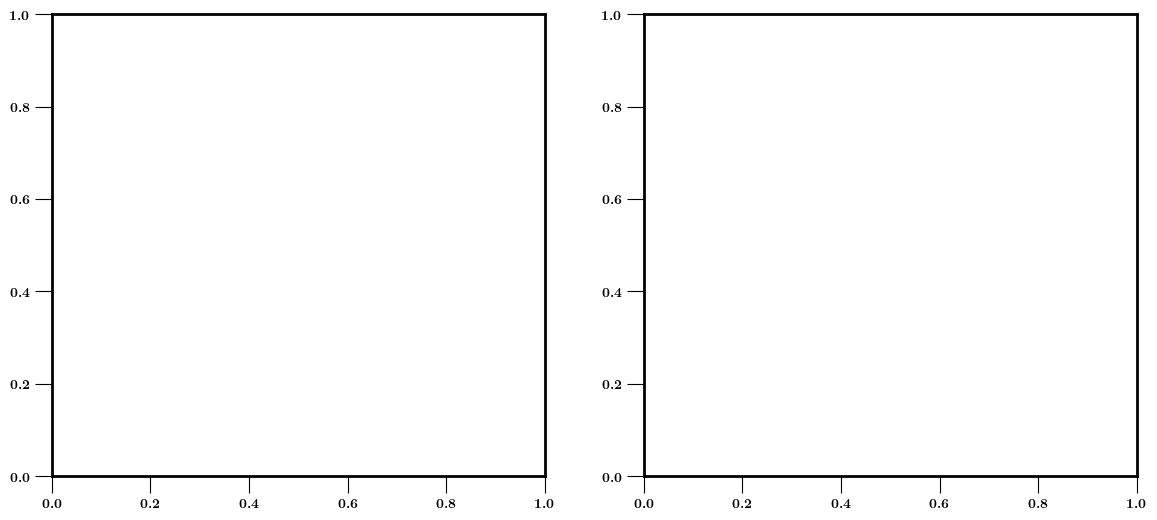

In [7]:
DCOtype = 'BH-BH'
csv_base = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'
channel_label='classic'
headers_ind_to_plot = 'channel I intrinsic (z=0) classic'



d1,d2, w_small = 14,6, 0.1 # overwrite 
ncols, nrows = 2, 1
f, axe= plt.subplots(ncols=ncols,nrows=nrows,figsize=(d1,d2), gridspec_kw={"width_ratios":[w_small]*ncols, "height_ratios":[ 1]}) 

# main function 

# main function 
plot_relations_review_single(axe=axe[0], csv_base=csv_base, headers_ind_to_plot=headers_ind_to_plot, DCOtype=DCOtype)
make_up_axes_param_review(axe=axe[0])
axe[0].set_ylim(0.01, 500)

plot_relations_review(axe=axe[1], csv_base=csv_base, headers_ind_to_plot=headers_ind_to_plot, DCOtype=DCOtype)
make_up_axes_param_review(axe=axe[1])
# plot_legends(axe=axe[0], csv_base=csv_base, DCOtype=DCOtype, parameters_list=False)

axe[1].set_ylim(0.01, 500)

plt.tight_layout()
plt.subplots_adjust(hspace=0.)
#         plt.savefig('./Parameter_impact_FC_'+fraction_label + '_' +channel_label + '.png', dpi=300, transparent=False)#,\
# plt.savefig('./GROWL_parameter_relations_review_' + channel_label + DCOtype+ '.pdf')#,\






In [ ]:
DCOtype = 'BH-BH'
csv_base = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'
channel_label='classic'
headers_ind_to_plot = 'channel I intrinsic (z=0) classic'



d1,d2, w_small = 16,6, 0.1 # overwrite 
ncols, nrows = 2, 1
f, axe= plt.subplots(ncols=ncols,nrows=nrows,figsize=(d1,d2), gridspec_kw={"width_ratios":[w_small]*ncols, "height_ratios":[ 1]}) 

# main function 

# main function 
plot_relations_review_single(axe=axe[0], csv_base=csv_base, headers_ind_to_plot=headers_ind_to_plot, DCOtype=DCOtype)
make_up_axes_param_review(axe=axe[0])
axe[0].set_ylim(0.01, 400)

plot_relations_review(axe=axe[1], csv_base=csv_base, headers_ind_to_plot=headers_ind_to_plot, DCOtype=DCOtype)
make_up_axes_param_review(axe=axe[1])
# plot_legends(axe=axe[0], csv_base=csv_base, DCOtype=DCOtype, parameters_list=False)

axe[1].set_ylim(0.01, 400)

for ii in [0,1]:
    axe[ii].fill_between(x=[0,1],y1=[17-6.7,17-6.7], y2=[37+24,37+24], color='gray', alpha=0.6, zorder=1)
    axe[ii].annotate(r'$\textbf{observations}$', xy=(0.01, 37+20), fontsize = fs-12, ha='left', va="top", zorder=100, color='white') #%xycoords='axes fraction'


plt.tight_layout()
plt.subplots_adjust(hspace=0.0)
#         plt.savefig('./Parameter_impact_FC_'+fraction_label + '_' +channel_label + '.png', dpi=300, transparent=False)#,\
plt.savefig('./GROWL_parameter_relations_review_' + channel_label + DCOtype+ '.pdf')#,\






In [ ]:


DCOtype = 'BH-BH'
csv_base = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

####
construct_full_relations_review_plot(channel_label='classic',  headers_ind_to_plot = 'channel I intrinsic (z=0) classic', csv_base=csv_base, DCOtype=DCOtype)
print('-----')
# plot_relations_review(channel_label='OSMT',  headers_ind_to_plot = 'channel II intrinsic (z=0) OSMT', csv_base=csv_base, DCOtype=DCOtype)






In [ ]:


def obtain_channels_list(complete_path='complete/path/to/data.csv'):
    """ returns list with channel column headers """
    df = pd.read_csv(complete_path)
    return df.columns.values[1:-1] # -1 because the last column is total rates. 


def obtain_total_header(complete_path='complete/path/to/data.csv'):
    """ returns column header for total """
    df = pd.read_csv(complete_path)
    return df.columns.values[-1] # -1 because the last column is total rates.     


def obtain_formation_channel_colors():
    channel_color_names = ['channel I intrinsic (z=0) classic', 'channel II intrinsic (z=0) OSMT', 'channel III intrinsic (z=0) SCCE',  'channel IV intrinsic (z=0) DCCE', 'channel V intrinsic (z=0) other']
    channel_colors = ['#118AB2',  'orange', '#EF476F','#073B4C',  'gray'] #['#118AB2',  '#FFD166', '#EF476F','#073B4C',  'gray']
    fc_color_dict = {channel_color_names[i]: channel_colors[i] for i in range(len(channel_color_names))}
    
    return fc_color_dict


def draw_hlines(axe, v_values, list_h_values=[1E-3, 1E5]):
    """ draws lightgray custom vertical grid lines at values in the v_values list 
    these are drawn between the horizontal values given by list_h_values
    """
    for v_ in v_values:
        axe.plot(list_h_values, [v_, v_], lw=0.5, c='gray', ls=':', zorder=0)
        
    return 


def plot_observed_GWrate(axe, DCOlabel='BH-BH', lenmodels=10):
    # plot observed rates (make this a better function )
    dict_rates_from_DCOlabel = {"BH-BH":[10.3, 61.0], "BH-NS":[8,  140.0], "NS-NS":[10.0, 1700.0]}
    # NSNS rates Gpc-3 yr-1 from:GWTC3 min & max rates 
    # BHBH rates for minimum and maximum of possible local merger rates estimates,  and https://ui.adsabs.harvard.edu/abs/2021arXiv210801045T/abstract
    # BHNS rate min and max range from the two estimates based on GW200115 and GW200105!! (OLD) ! 
    
    min_obs_rate, max_obs_rate = dict_rates_from_DCOlabel[DCOlabel][0], dict_rates_from_DCOlabel[DCOlabel][1]
    axe.fill_betweenx(y=[-1, lenmodels], x1=[min_obs_rate,min_obs_rate], x2=[max_obs_rate,max_obs_rate], alpha=0.8, color='lightgray', zorder=1)
        

    return


def plot_formation_channels_fraction(axe, complete_path='complete/path/to/data.csv', sort_column=None):
    """   
    
    """

    channel_headers = obtain_channels_list(complete_path=complete_path)
    print(channel_headers)
    total_header = obtain_total_header(complete_path=complete_path)
    
    fc_color_dict = obtain_formation_channel_colors() # obtain formation channel colors 
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    
    df = pd.read_csv(complete_path)
    df = df.sort_values(sort_column).reset_index(drop=True)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    #.reset_index(drop=True) resets the index, so that index = 0 is the first element in the sorted list (not original list)
    
    
    models = df['model'] # models that are available 
    plot_size_normalizer = 1 # change to be related to figure size and number of models to keep figure consistent size

    for ind_m, model in enumerate(models):
        total_rate, fc_fraction_low, fc_fraction_up = df[total_header][ind_m], 0, 0
        for ind_c, channel in enumerate([channel_headers[0]]):
            color_c = fc_color_dict[channel]
            fc_fraction_up += df[channel].values[ind_m] 
            y_value        = ind_m / plot_size_normalizer # 
            
#             axe.plot([fc_fraction_low, fc_fraction_up], [y_value,y_value], lw=10, color=color_c, zorder=5) #, marker='o') 
            axe.plot([fc_fraction_low, fc_fraction_up], [y_value,y_value], lw=10, color=color_c, zorder=5) #, marker='o') 
            fc_fraction_low += df[channel].values[ind_m]
    
    axe.set_ylim(-1, len(models)+0.25)
    axe.set_xlim(0, 1)
    axe.set_xticks(np.arange(0,1+0.1, 0.5))
    layoutAxesNoYlabel(ax=axe, nameX=r'$\% \textbf{ with CE}$', nameY=False, noYticks=True, setMinor=False, fontsize=24)
    
    axe.grid(True)
    
    return axe


def plot_total_rate(axe, complete_path='complete/path/to/data.csv', sort_column=None, DCOlabel='BH-BH'):
    """ plots total rates on provided axe plot 
    """


    channel_headers = obtain_channels_list(complete_path=complete_path)
    total_header = obtain_total_header(complete_path=complete_path)
    
    fc_color_dict = obtain_formation_channel_colors() # obtain formation channel colors 
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    
    df = pd.read_csv(complete_path)
    df = df.sort_values(sort_column).reset_index(drop=True)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    #.reset_index(drop=True) resets the index, so that index = 0 is the first element in the sorted list (not original list)
    
    models = df['model'] # models that are available     
    plot_size_normalizer = 1 # change to be related to figure size and number of models to keep figure consistent size
    
    for ind_m, model in enumerate(models):
        
        total_rate = df[total_header][ind_m]
        y_value        = ind_m / plot_size_normalizer # 
        axe.scatter(total_rate, y_value, s=60, color=['k'], zorder=10, marker='d') 

        draw_hlines(axe=axe, v_values=[y_value]) # add custom grid lines
    
    axe.set_ylim(-1, len(models)+0.25)
    xlabel = r'$\mathcal{R}_{\rm{m}} \ [ \rm{Gpc}^{-3} \rm{yr}^{-1} ] $' #\rm{Gpc}^{-3}\,\rm{yr}^{-1}
    layoutAxesNoYlabel(ax=axe, nameX=xlabel, nameY=False, noYticks=True) #, fontsize=20)
    
    axe.set_xscale('log')
    dictDCOlabel_xlim = {"BH-BH":[2, 500], "BH-NS":[0.2,400], "NS-NS":[0.5, 2*1E3]} # limits for the x-axis range for each DCO type 
    axe.set_xlim(dictDCOlabel_xlim[DCOlabel][0], dictDCOlabel_xlim[DCOlabel][1])
    
    ## add observed merger rates
    lenmodels = len(models)+0.25
    plot_observed_GWrate(axe, DCOlabel, lenmodels)
    

    return axe




def plot_formation_channels_rate(axe, complete_path='complete/path/to/data.csv', sort_column=None): #, ind_channels=[0,1, 2, 3]):


    channel_headers = obtain_channels_list(complete_path=complete_path) 
    total_header = obtain_total_header(complete_path=complete_path)
    
    fc_color_dict = obtain_formation_channel_colors() # obtain formation channel colors 
    
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    
    
    df = pd.read_csv(complete_path)
    df = df.sort_values(sort_column).reset_index(drop=True)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    #.reset_index(drop=True) resets the index, so that index = 0 is the first element in the sorted list (not original list)
    
    models = df['model'] # models that are available 
    plot_size_normalizer = 1 # change to be related to figure size and number of models to keep figure consistent size
    for ind_m, model in enumerate(models):
        total_rate = df[total_header][ind_m]
        for ind_c, channel in enumerate([channel_headers[0]]):
            color_c = fc_color_dict[channel]
            y_value        = ind_m / plot_size_normalizer # 
            channel_rate = df[channel].values[ind_m]*total_rate
            
            axe.scatter(channel_rate, y_value, s=50, color=[color_c], zorder=5, marker='s', facecolor='none') 
    
    return axe





def plot_simulation_properties(axe, specs_path='complete/path/to/simulation_specs.csv', complete_path='complete/path/to/simulation_specs.csv', sort_column=None):

    channel_headers = obtain_channels_list(complete_path=complete_path) 
    
    
    
    
    if sort_column==None: sort_column=channel_headers[0] # if not specified, sort by Classic channel
    df_rates = pd.read_csv(complete_path) # path with the rates 
    df_rates = df_rates.sort_values(sort_column)  # can use df = df.sort_values([sort_column, sort_column2]) if needed to sort by second column 
    
    # read in model specifications and order it the same way as the rate models (based on sort_column)
    df = pd.read_csv(specs_path)
    df = df.set_index('model')
    df = df.reindex(index=df_rates['model'])
    df = df.reset_index()
    
    models = df['model'] # models that are available 
    plot_size_normalizer = 1 # change in the future to be related to figure size and number of models to keep figure consistent size
    author_dict, code_dict, tracks_dict, labeli_dict, labelii_dict = obtain_models_colors(specs_path, "label_author", "husl"), obtain_models_colors(specs_path, "code", "husl"), obtain_models_colors(specs_path, "stellar_tracks", "husl"),\
    obtain_models_colors(specs_path, "label_1", "husl"), obtain_models_colors(specs_path, "label_1", "husl") # colors for label 1 are the same as label 2 
    
    
    xpositions = 0.02 + np.asarray([-0.2, 0, 0.3, 0.51, 0.8]) #, 0.75])
    for ind_m, model in enumerate(models[:]):
#         
        specs_labels = [df["label_author"][ind_m], df["code"][ind_m], df["stellar_tracks"][ind_m], df["label_1"][ind_m] , df["label_2"][ind_m]]
        colors_ = [author_dict[df["label_author"][ind_m]], code_dict[df["code"][ind_m]], tracks_dict[df["stellar_tracks"][ind_m]], labeli_dict[df["label_1"][ind_m]] , labelii_dict[df["label_2"][ind_m]]] # 
        y_value        = ind_m / plot_size_normalizer # 
        
        
        for ind_xpos, xpos in enumerate(xpositions):
            text = r'\textbf{%s}'%specs_labels[ind_xpos]
            axe.text(xpos, y_value, s=text, ha='left', va='center', fontsize=9, fontproperties='bold', color=colors_[ind_xpos])
    
    
    
    # add headers to the specs
    labels = [r'$\textbf{name}$', r'$\textbf{code}$', r'$\textbf{tracks}$', r'$\textbf{var1}$', r'$\textbf{var2}$']
    for ind_xpos, xpos in enumerate(xpositions):
        
        axe.text(xpos, y_value+1.2, s=labels[ind_xpos], ha='left', va='top', fontsize=12)
    
    axe.set_ylim((-1, len(models)+0.25))
    axe.set_xlim(0, 1)
#     layoutAxesNoXandYlabel(ax=axe, nameX=r'$\textbf{fraction rate}$', nameY=False, noYticks=True)
    axe.axis('off')
    return axe



def obtain_models_colors(path_to_data='complete/path/to/simulation_specs.csv', color_key="code_abbr", cmap="husl"):
    """ creates a colormap for set of provided parameters using given cmap
    
    path_to_data: path to csv file with the data that we want to use as keys
    color_key: header name of the values we want to use as keys
    cmap: colormap used 

    """
    
    data = pd.read_csv(path_to_data)[color_key].values 
    
    # if interested in the model labels, combine the two model labels to make them consistent
    if color_key == "label_1":
        data2 = pd.read_csv(path_to_data)["label_2"].values 
        data = np.concatenate((data, data2))
        del data2
        
    data = [str(data[i]) for i in range(len(data))] # to deal with nan and np.unique make everything a string. 
    models = np.unique(data) # get unique items, these will be assigned their own color. 
    colors =  sns.color_palette(cmap, len(models)) #make a color map 
    
    return dict(zip(models, colors))




In [ ]:

DCOlabel = 'BH-BH'
ordered = 'max'
file_name = DCOlabel + '_rates_review.csv'


# complete_path = path_to_file + file_name
specs_path = path_to_file + 'simulation_specs.csv'
csv_path = path_to_file + file_name

d1,d2 = 14,15 # overwrite 
w_small = 0.3
ncols, nrows = 3, 1
f, axe= plt.subplots(ncols=ncols,nrows=nrows,figsize=(d1,d2), gridspec_kw={"width_ratios":[w_small*1.1, 1.8*w_small, w_small], "height_ratios":[1]})  



axe[0] = plot_simulation_properties(axe=axe[0], specs_path=specs_path, complete_path=csv_path) # plot the simulation specifics 
axe[1] = plot_formation_channels_fraction(axe=axe[1], complete_path=csv_path)
axe[2] = plot_total_rate(axe=axe[2], complete_path=csv_path, DCOlabel=DCOlabel)
axe[2] = plot_formation_channels_rate(axe=axe[2], complete_path=csv_path)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.0)  
plt.savefig('./FormationRates_' +DCOlabel+ '_' + ordered + 'sorted' + 'NSF.png', dpi=300, transparent=False)#,\
plt.savefig('./FormationRates_' +DCOlabel+ '_' + ordered + 'sorted' + 'NSF.pdf')#,\
plt.show()




In [ ]:
def threePartBrokenPowerLaw(x, x1=0.01, x2=0.08, x3=0.5, x4=200, a1=-0.3, \
                            a2=-1.3, a3=-2.3, C1=1):
    #Not that everything outside the range x1<x4 is set to zero
    yvalues = np.zeros(len(x))
    
    #calculate values of the x values that are x1<=x<x2
    mask1 = (x>=x1) & (x<x2)
    yvalues[mask1] = C1 * (x[mask1]**a1)
    
    #calculate values of the x values that are x2<=x<x3
    mask2 = (x>=x2) & (x<x3)
    C2    = C1 * (x2**(a1-a2))
    yvalues[mask2] = C2 * (x[mask2]**a2)
    
    #calculate values of the x values that are x3<=x<=x4
    mask3 = (x>=x3) & (x<=x4)
    C3    = C1 * (x2**(a1-a2)) * (x3**(a2-a3))
    yvalues[mask3] = C3 * (x[mask3]**a3)
    
    return yvalues

def CDFbrokenPowerLaw(x, x1, x2, x3, x4, a1, a2, a3, C1):
    yvalues = np.zeros(len(x))
    
    C2    = float(C1 * (x2**(a1-a2)))
    C3    = float(C2 * (x3**(a2-a3)))
    
    N1 = float(((1./(a1+1)) * C1 * (x2**(a1+1))) - ((1./(a1+1)) * C1 * (x1**(a1+1))))
    N2 = float(((1./(a2+1)) * C2 * (x3**(a2+1))) - ((1./(a2+1)) * C2 * (x2**(a2+1))))
    N3 = float(((1./(a3+1)) * C3 * (x4**(a3+1))) - ((1./(a3+1)) * C3 * (x3**(a3+1))))
    
    bottom = N1+N2+N3
    
    mask1 = (x>=x1) & (x<x2)
    top1 = (((1./(a1+1)) * C1 * (x[mask1]**(a1+1)) - (1./(a1+1)) * C1 * (x1**(a1+1))))
    yvalues[mask1] = top1/bottom
    
    #calculate values of the x values that are x2<=x<x3
    mask2 = (x>=x2) & (x<x3)
    top2 =  N1 + (((1./(a2+1)) * C2 * (x[mask2]**(a2+1)) - (1./(a2+1)) * C2 * (x2**(a2+1))))
    yvalues[mask2] = top2/bottom
    
    #calculate values of the x values that are x3<=x<=x4
    mask3 = (x>=x3) & (x<=x4)
    top3 =  N1 + N2 + (((1./(a3+1)) * C3 * (x[mask3]**(a3+1)) - (1./(a3+1)) * C3 * (x3**(a3+1))))
    yvalues[mask3] = top3/bottom
    return yvalues


def invertCDFbrokenPowerLaw(CDF, x1, x2, x3, x4, a1, a2, a3, C1):
    #I specifically do floats against python rounding when dividing
    
    #The constants needed
    C2    = float(C1 * (x2**(a1-a2)))
    C3    = float(C2 * (x3**(a2-a3)))
    
    N1 = float(((1./(a1+1)) * C1 * (x2**(a1+1))) - ((1./(a1+1)) * C1 * (x1**(a1+1))))
    N2 = float(((1./(a2+1)) * C2 * (x3**(a2+1))) - ((1./(a2+1)) * C2 * (x2**(a2+1))))
    N3 = float(((1./(a3+1)) * C3 * (x4**(a3+1))) - ((1./(a3+1)) * C3 * (x3**(a3+1))))
    
    bottom = N1+N2+N3
    
    CDFx2 = CDFbrokenPowerLaw(np.array([x2,x2]), x1, x2, x3, x4, a1, a2, a3, C1)[0]
    CDFx3 = CDFbrokenPowerLaw(np.array([x3,x3]), x1, x2, x3, x4, a1, a2, a3, C1)[0]

    
    xvalues = np.zeros(len(CDF))
    
    mask1 = (CDF < CDFx2)
    xvalues[mask1] =  (((CDF[mask1]*(N1+N2+N3))  + \
                      ( (1./(a1+1))*C1*(x1**(a1+1))))/((1./(a1+1))*C1))**(1./(a1+1))
    
    mask2 = (CDFx2<= CDF) & (CDF < CDFx3)
    xvalues[mask2] = ((((CDF[mask2]*(N1+N2+N3))-(N1))  + \
                      ( (1./(a2+1))*C2*(x2**(a2+1))))/((1./(a2+1))*C2))**(1./(a2+1))
    
    mask3 = (CDFx3<= CDF) 
    xvalues[mask3] = ((((CDF[mask3]*(N1+N2+N3))-(N1+N2))  + \
                      ((1./(a3+1))*C3*(x3**(a3+1))))/((1./(a3+1))*C3))**(1./(a3+1))
    
    return xvalues

x1=0.01
x2=0.08
x3=0.5
x4=200
a1=+0.
                            
a2=+.5
a3=+1.1
C1=1
sampleSize=200000000
Mmin=1
Mmax=500


CDFmin = CDFbrokenPowerLaw(np.array([Mmin]), x1, x2, x3, x4, a1, a2, a3, C1)
CDFmax = CDFbrokenPowerLaw(np.array([Mmax]), x1, x2, x3, x4, a1, a2, a3, C1)

#All the random drawing that we need
drawM1         = np.random.uniform(CDFmin,CDFmax,sampleSize)
drawBinary     = np.random.uniform(0,1,sampleSize)
drawM2         = np.random.uniform(0,1,sampleSize)

#All the arrays we want to fill
M1 = np.zeros(sampleSize)
M2 = np.zeros(sampleSize)

#Define the IMF broken powerlaw and calculate masses from inverted CDF


M1 = invertCDFbrokenPowerLaw(drawM1, x1, x2, x3, x4, a1, a2, a3, C1)
M2 = invertCDFbrokenPowerLaw(drawM2, x1, x2, x3, x4, a1, a2, a3, C1)
print(np.max(invertCDFbrokenPowerLaw(drawM1, x1, x2, x3, x4, a1, a2, a3, C1)))

In [ ]:
def threePartBrokenPowerLaw(x, x1=0.01, x2=0.08, x3=0.5, x4=200, a1=-0.3, \
                            a2=-1.3, a3=-2.3, C1=1):
    #Not that everything outside the range x1<x4 is set to zero
    yvalues = np.zeros(len(x))
    
    #calculate values of the x values that are x1<=x<x2
    mask1 = (x>=x1) & (x<x2)
    yvalues[mask1] = C1 * (x[mask1]**a1)
    
    #calculate values of the x values that are x2<=x<x3
    mask2 = (x>=x2) & (x<x3)
    C2    = C1 * (x2**(a1-a2))
    yvalues[mask2] = C2 * (x[mask2]**a2)
    
    #calculate values of the x values that are x3<=x<=x4
    mask3 = (x>=x3) & (x<=x4)
    C3    = C1 * (x2**(a1-a2)) * (x3**(a2-a3))
    yvalues[mask3] = C3 * (x[mask3]**a3)
    
    return yvalues

def CDFbrokenPowerLaw(x, x1, x2, x3, x4, a1, a2, a3, C1):
    yvalues = np.zeros(len(x))
    
    C2    = float(C1 * (x2**(a1-a2)))
    C3    = float(C2 * (x3**(a2-a3)))
    
    N1 = float(((1./(a1+1)) * C1 * (x2**(a1+1))) - ((1./(a1+1)) * C1 * (x1**(a1+1))))
    N2 = float(((1./(a2+1)) * C2 * (x3**(a2+1))) - ((1./(a2+1)) * C2 * (x2**(a2+1))))
    N3 = float(((1./(a3+1)) * C3 * (x4**(a3+1))) - ((1./(a3+1)) * C3 * (x3**(a3+1))))
    
    bottom = N1+N2+N3
    
    mask1 = (x>=x1) & (x<x2)
    top1 = (((1./(a1+1)) * C1 * (x[mask1]**(a1+1)) - (1./(a1+1)) * C1 * (x1**(a1+1))))
    yvalues[mask1] = top1/bottom
    
    #calculate values of the x values that are x2<=x<x3
    mask2 = (x>=x2) & (x<x3)
    top2 =  N1 + (((1./(a2+1)) * C2 * (x[mask2]**(a2+1)) - (1./(a2+1)) * C2 * (x2**(a2+1))))
    yvalues[mask2] = top2/bottom
    
    #calculate values of the x values that are x3<=x<=x4
    mask3 = (x>=x3) & (x<=x4)
    top3 =  N1 + N2 + (((1./(a3+1)) * C3 * (x[mask3]**(a3+1)) - (1./(a3+1)) * C3 * (x3**(a3+1))))
    yvalues[mask3] = top3/bottom
    return yvalues


def invertCDFbrokenPowerLaw(CDF, x1, x2, x3, x4, a1, a2, a3, C1):
    #I specifically do floats against python rounding when dividing
    
    #The constants needed
    C2    = float(C1 * (x2**(a1-a2)))
    C3    = float(C2 * (x3**(a2-a3)))
    
    N1 = float(((1./(a1+1)) * C1 * (x2**(a1+1))) - ((1./(a1+1)) * C1 * (x1**(a1+1))))
    N2 = float(((1./(a2+1)) * C2 * (x3**(a2+1))) - ((1./(a2+1)) * C2 * (x2**(a2+1))))
    N3 = float(((1./(a3+1)) * C3 * (x4**(a3+1))) - ((1./(a3+1)) * C3 * (x3**(a3+1))))
    
    bottom = N1+N2+N3
    
    CDFx2 = CDFbrokenPowerLaw(np.array([x2,x2]), x1, x2, x3, x4, a1, a2, a3, C1)[0]
    CDFx3 = CDFbrokenPowerLaw(np.array([x3,x3]), x1, x2, x3, x4, a1, a2, a3, C1)[0]

    
    xvalues = np.zeros(len(CDF))
    
    mask1 = (CDF < CDFx2)
    xvalues[mask1] =  (((CDF[mask1]*(N1+N2+N3))  + \
                      ( (1./(a1+1))*C1*(x1**(a1+1))))/((1./(a1+1))*C1))**(1./(a1+1))
    
    mask2 = (CDFx2<= CDF) & (CDF < CDFx3)
    xvalues[mask2] = ((((CDF[mask2]*(N1+N2+N3))-(N1))  + \
                      ( (1./(a2+1))*C2*(x2**(a2+1))))/((1./(a2+1))*C2))**(1./(a2+1))
    
    mask3 = (CDFx3<= CDF) 
    xvalues[mask3] = ((((CDF[mask3]*(N1+N2+N3))-(N1+N2))  + \
                      ((1./(a3+1))*C3*(x3**(a3+1))))/((1./(a3+1))*C3))**(1./(a3+1))
    
    return xvalues

x1=0.01
x2=0.08
x3=0.5
x4=200
a1=+0.
                            
a2=+.0
a3=+.1 
C1=1
sampleSize=200000000
Mmin=1
Mmax=500


CDFmin = CDFbrokenPowerLaw(np.array([Mmin]), x1, x2, x3, x4, a1, a2, a3, C1)
CDFmax = CDFbrokenPowerLaw(np.array([Mmax]), x1, x2, x3, x4, a1, a2, a3, C1)

#All the random drawing that we need
# drawM1         = np.random.uniform(CDFmin,CDFmax,sampleSize)
# drawBinary     = np.random.uniform(0,1,sampleSize)
drawM2         = np.random.uniform(0,1,sampleSize)

#All the arrays we want to fill
# M1 = np.zeros(sampleSize)
M2 = np.zeros(sampleSize)

#Define the IMF broken powerlaw and calculate masses from inverted CDF


# M1 = invertCDFbrokenPowerLaw(drawM1, x1, x2, x3, x4, a1, a2, a3, C1)
M2 = invertCDFbrokenPowerLaw(drawM2, x1, x2, x3, x4, a1, a2, a3, C1)
print(np.max(invertCDFbrokenPowerLaw(drawM1, x1, x2, x3, x4, a1, a2, a3, C1)))

In [ ]:
import matplotlib.pyplot as plt 
import numpy as np 
  
f, axe= plt.subplots(1,1,figsize=(8,6))
# Create a 2-D histogram 
plt.hist2d(M1*350, M2/100, bins=(50, 50), cmap='viridis', density=True) 
plt.colorbar() 
  
# Add labels and title 
# plt.xlabel(r'\textbf{Mass Star} $[M_{\odot}]$', fontsize=24) 
# plt.xlabel(r'\textbf{Metallicity} $[M_{\odot}]$', fontsize=24) 
# plt.title('2-D Histogram') 
xlabel=r'\textbf{Mass Star} $[M_{\odot}]$'
ylabel=r'\textbf{Metallicity} '
axe=layoutAxes(ax=axe, nameX=xlabel, nameY=ylabel )
# Display the plot 
plt.show()